In [10]:
%load_ext autoreload
%autoreload 2
import numpy as np
from sys import path
path.insert(0, '..')
from scripts.PCA import train_PCA,apply_PCA
from scripts.utility import map_labels_into_numbers,compute_Sb_Sw,getMu,vCol,vRow
from scripts.LDA import train_LDA,apply_LDA
import pandas as pd
import scipy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
df_train=pd.read_csv('../data/train.csv')
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [5]:
X_train_raw=df_train.iloc[:,:-1].values
labels=df_train.iloc[:,-1].values
labels

array(['STANDING', 'STANDING', 'STANDING', ..., 'WALKING_UPSTAIRS',
       'WALKING_UPSTAIRS', 'WALKING_UPSTAIRS'],
      shape=(7352,), dtype=object)

In [6]:
labels_to_num,num_to_label,labels_n=map_labels_into_numbers(labels)
labels_n

array([2, 2, 2, ..., 5, 5, 5], shape=(7352,))

In [7]:
import json

json.dump(num_to_label, open('../data/processed/num_to_label.json', 'w'))
json.dump(labels_to_num, open('../data/processed/labels_to_num.json', 'w'))

In [8]:
D_train=X_train_raw.T # -->(feature, samples)
D_train.shape

(562, 7352)

In [11]:
P,mu=train_PCA(D_train,20)
DP=apply_PCA(D_train,P,mu)
DP.shape

(20, 7352)

In [12]:
D_train.mean(axis=1).shape

(562,)

In [13]:
W=train_LDA(DP,labels_n,5)
DP_lda=apply_LDA(DP,W)

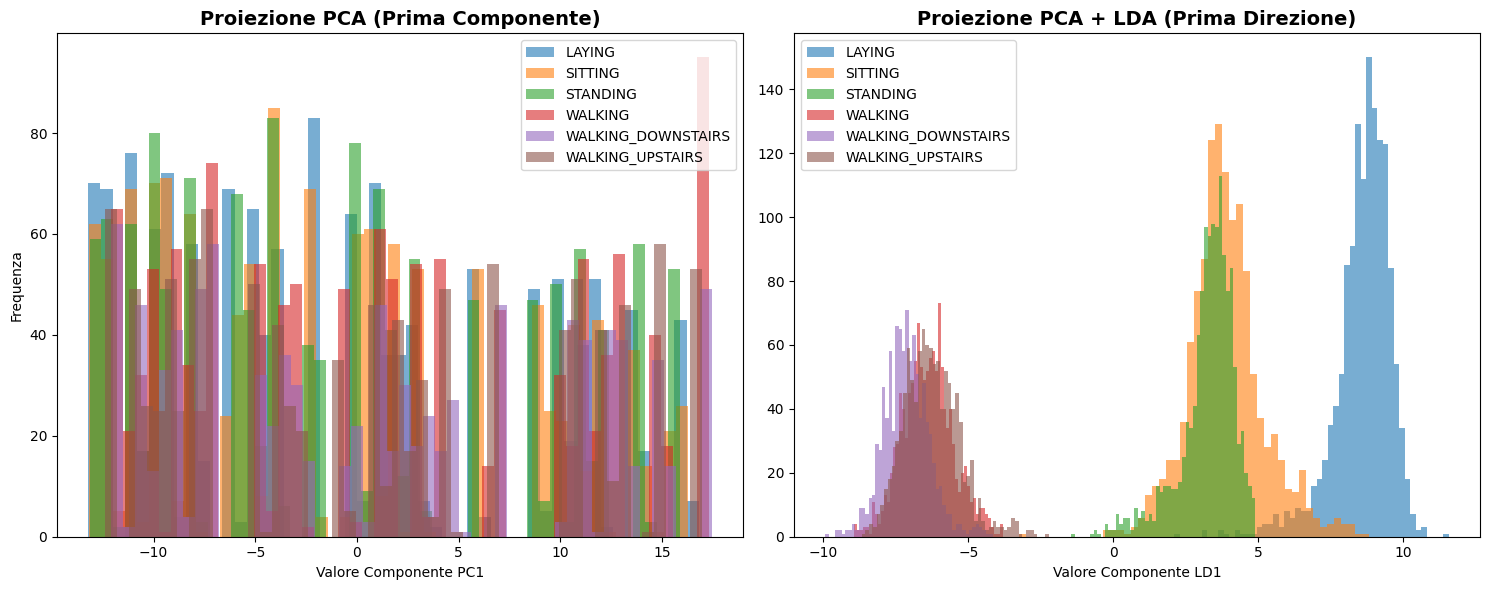

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_histograms(DP_pca, DP_lda, labels, num_to_label):
    # Creiamo una figura con due grafici affiancati
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Colori per le classi (fino a 6 classi)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    # Classi uniche
    classes = np.unique(labels)
    
    # --- GRAFICO 1: Istogramma della PCA (Prima Componente) ---
    ax1 = axes[0]
    for c in classes:
        # Estraiamo solo i valori della prima riga (PC1) per la classe 'c'
        data_c = DP_pca[0, labels == c]
        label_name = num_to_label[c]
        ax1.hist(data_c, bins=50, alpha=0.6, label=label_name, color=colors[c % len(colors)])
    
    ax1.set_title("Proiezione PCA (Prima Componente)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Valore Componente PC1")
    ax1.set_ylabel("Frequenza")
    ax1.legend()
    
    # --- GRAFICO 2: Istogramma dell'LDA (Prima Direzione Discriminante) ---
    ax2 = axes[1]
    for c in classes:
        # Estraiamo solo i valori della prima riga (LD1) per la classe 'c'
        data_c = DP_lda[0, labels == c]
        label_name = num_to_label[c]
        ax2.hist(data_c, bins=50, alpha=0.6, label=label_name, color=colors[c % len(colors)])
    
    ax2.set_title("Proiezione PCA + LDA (Prima Direzione)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Valore Componente LD1")
    ax2.legend()
    
    # Mostriamo il risultato
    plt.tight_layout()
    plt.show()

plot_histograms(DP, DP_lda, labels_n, num_to_label)

In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/D_train_latent.npy', DP_lda)
np.save('../data/processed/L_train.npy', labels_n)

In [17]:
df_test=pd.read_csv('../data/test.csv')
df_test.head()
X_test=df_test.iloc[:,:-1].values
L_test=df_test.iloc[:,-1].values
_,_,L_test_n=map_labels_into_numbers(L_test)

X_test_PCA=apply_PCA(X_test.T,P,mu)
X_test_LDA=apply_LDA(X_test_PCA,W)

X_test_LDA.shape

(5, 2947)

In [18]:
np.save('../data/processed/D_test.npy',X_test_LDA)
np.save('../data/processed/L_test.npy',L_test_n)